In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
import statsmodels.formula.api as smf

In [4]:
# Display settings
pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")

In [5]:
df = pd.read_excel('full_data.xlsx')

In [6]:
df.head(10)

,Company,Year,Net Income (€M),Book Value of Equity (€M),Market Value (€M),Period
0,Accor,2015,244,3762,8300,Pre-Covid
1,Accor,2016,265,5925,9500,Pre-Covid
2,Accor,2017,441,5826,10200,Pre-Covid
3,Accor,2018,2233,6436,10500,Pre-Covid
4,Accor,2019,464,6978,11000,Pre-Covid
5,Accor,2020,-1988,4158,6500,Covid
6,Accor,2021,85,4549,7500,Covid
7,Accor,2022,392,4580,8200,War
8,Accor,2023,633,4931,8700,War
9,Airbus,2015,2696,10106,55000,Pre-Covid


In [7]:
df.columns = df.columns.str.strip()


In [13]:
print("Shape of dataset:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head()

Shape of dataset: (585, 6)

Columns: ['Company', 'Year', 'Net Income (€M)', 'Book Value of Equity (€M)', 'Market Value (€M)', 'Period']


,Company,Year,Net Income (€M),Book Value of Equity (€M),Market Value (€M),Period
0,Accor,2015,244,3762,8300,Pre-Covid
1,Accor,2016,265,5925,9500,Pre-Covid
2,Accor,2017,441,5826,10200,Pre-Covid
3,Accor,2018,2233,6436,10500,Pre-Covid
4,Accor,2019,464,6978,11000,Pre-Covid


In [15]:
# Check for missing values
print("\nMissing values per column:")
print(df.isnull().sum())


Missing values per column:
Company                      0
Year                         0
Net Income (€M)              0
Book Value of Equity (€M)    0
Market Value (€M)            0
Period                       0
dtype: int64


In [17]:
# Check number of unique companies and years
print("\nNumber of unique companies:", df['Company'].nunique())
print("Years in dataset:", sorted(df['Year'].unique()))
print("Observations per year:")
print(df['Year'].value_counts().sort_index())


Number of unique companies: 65
Years in dataset: [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]
Observations per year:
Year
2015    65
2016    65
2017    65
2018    65
2019    65
2020    65
2021    65
2022    65
2023    65
Name: count, dtype: int64


In [19]:
# Check unique values in period column
print("\nUnique values in Period column:", df['Period'].unique())
print("Observations per period:")
print(df['Period'].value_counts())


Unique values in Period column: ['Pre-Covid' 'Covid' 'War']
Observations per period:
Period
Pre-Covid    325
Covid        130
War          130
Name: count, dtype: int64


In [21]:
# Descriptive stats for financial variables
df[['Net Income (€M)', 'Book Value of Equity (€M)', 'Market Value (€M)']].describe()

,Net Income (€M),Book Value of Equity (€M),Market Value (€M)
count,585.000000,585.000000,585.000000
mean,1007.740171,9455.319658,23493.333333
std,2330.699165,12194.658056,40054.404674
min,-17940.000000,-4152.000000,85.000000
25%,160.000000,1908.000000,4000.000000
50%,416.000000,4103.000000,9970.000000
75%,1287.000000,12000.000000,26000.000000
max,24692.000000,62701.000000,394310.000000


In [23]:
# Find entries with negative or zero market value or book value
df[(df['Market Value (€M)'] <= 0) | (df['Book Value of Equity (€M)'] <= 0)]


,Company,Year,Net Income (€M),Book Value of Equity (€M),Market Value (€M),Period
23,Air France-KLM,2020,-7078,-1725,1800,Covid
24,Air France-KLM,2021,-3292,-4152,2500,Covid
25,Air France-KLM,2022,728,-2424,3200,War


In [25]:
#  Preparing the data for panel regression:
#  Set multi-index (Company, Year)
# -Encode 'Period' as category
# Add log variables if needed later for normalization or scale sensitivity

df.set_index(['Company', 'Year'], inplace=True)
df['Period'] = df['Period'].astype('category')

In [27]:
# Check period distribution across years and firms
print("Observations per Period:")
print(df['Period'].value_counts())

Observations per Period:
Period
Pre-Covid    325
Covid        130
War          130
Name: count, dtype: int64


In [29]:
df.head()

Net Income (€M)  Book Value of Equity (€M)  Market Value (€M)  \
Company Year                                                                  
Accor   2015              244                       3762               8300   
        2016              265                       5925               9500   
        2017              441                       5826              10200   
        2018             2233                       6436              10500   
        2019              464                       6978              11000   

                 Period  
Company Year             
Accor   2015  Pre-Covid  
        2016  Pre-Covid  
        2017  Pre-Covid  
        2018  Pre-Covid  
        2019  Pre-Covid

In [31]:
# creating scaled versions (in € billions) for regression

df['Net_Income_B'] = df['Net Income (€M)'] / 1000
df['Book_Value_B'] = df['Book Value of Equity (€M)'] / 1000
df['Market_Value_B'] = df['Market Value (€M)'] / 1000


df[['Net_Income_B', 'Book_Value_B', 'Market_Value_B']].describe()



,Net_Income_B,Book_Value_B,Market_Value_B
count,585.000000,585.000000,585.000000
mean,1.007740,9.455320,23.493333
std,2.330699,12.194658,40.054405
min,-17.940000,-4.152000,0.085000
25%,0.160000,1.908000,4.000000
50%,0.416000,4.103000,9.970000
75%,1.287000,12.000000,26.000000
max,24.692000,62.701000,394.310000


In [33]:

# df['Net Income (€B)'] = df['Net Income (€M)'] / 1000
# df['Book Value of Equity (€B)'] = df['Book Value of Equity (€M)'] / 1000
# df['Market Value (€B)'] = df['Market Value (€M)'] / 1000

# # Preview new columns
# df[['Net Income (€B)', 'Book Value of Equity (€B)', 'Market Value (€B)']].describe()



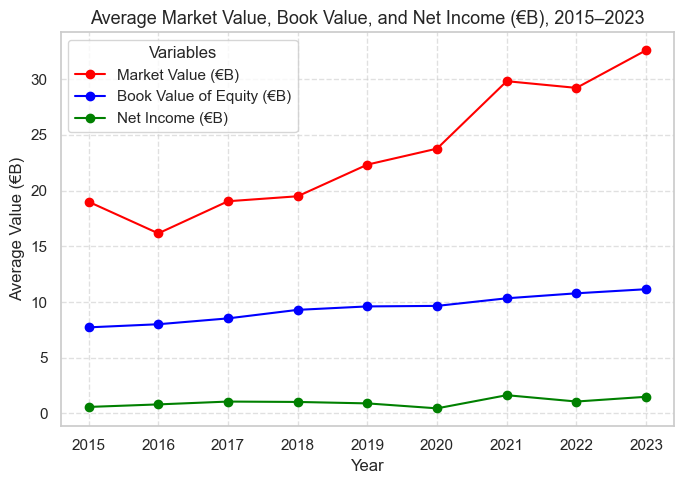

In [35]:
# Compute yearly averages for the three variables
avg_values = df.groupby('Year')[['Market_Value_B', 'Book_Value_B', 'Net_Income_B']].mean().reset_index()

# Create the line plot
plt.figure(figsize=(7, 5))
plt.plot(avg_values['Year'], avg_values['Market_Value_B'], marker='o', color= 'Red', label='Market Value (€B)')
plt.plot(avg_values['Year'], avg_values['Book_Value_B'], marker='o', color='Blue', label='Book Value of Equity (€B)')
plt.plot(avg_values['Year'], avg_values['Net_Income_B'], marker='o', color='Green', label='Net Income (€B)')

# Add title and labels
plt.title('Average Market Value, Book Value, and Net Income (€B), 2015–2023', fontsize=13)
plt.xlabel('Year')
plt.ylabel('Average Value (€B)')

# Add grid, legend, and tight layout
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Variables', loc='upper left', frameon=True)
plt.tight_layout()
plt.savefig("avg_values_plot.png", dpi=300, bbox_inches='tight')
plt.show()

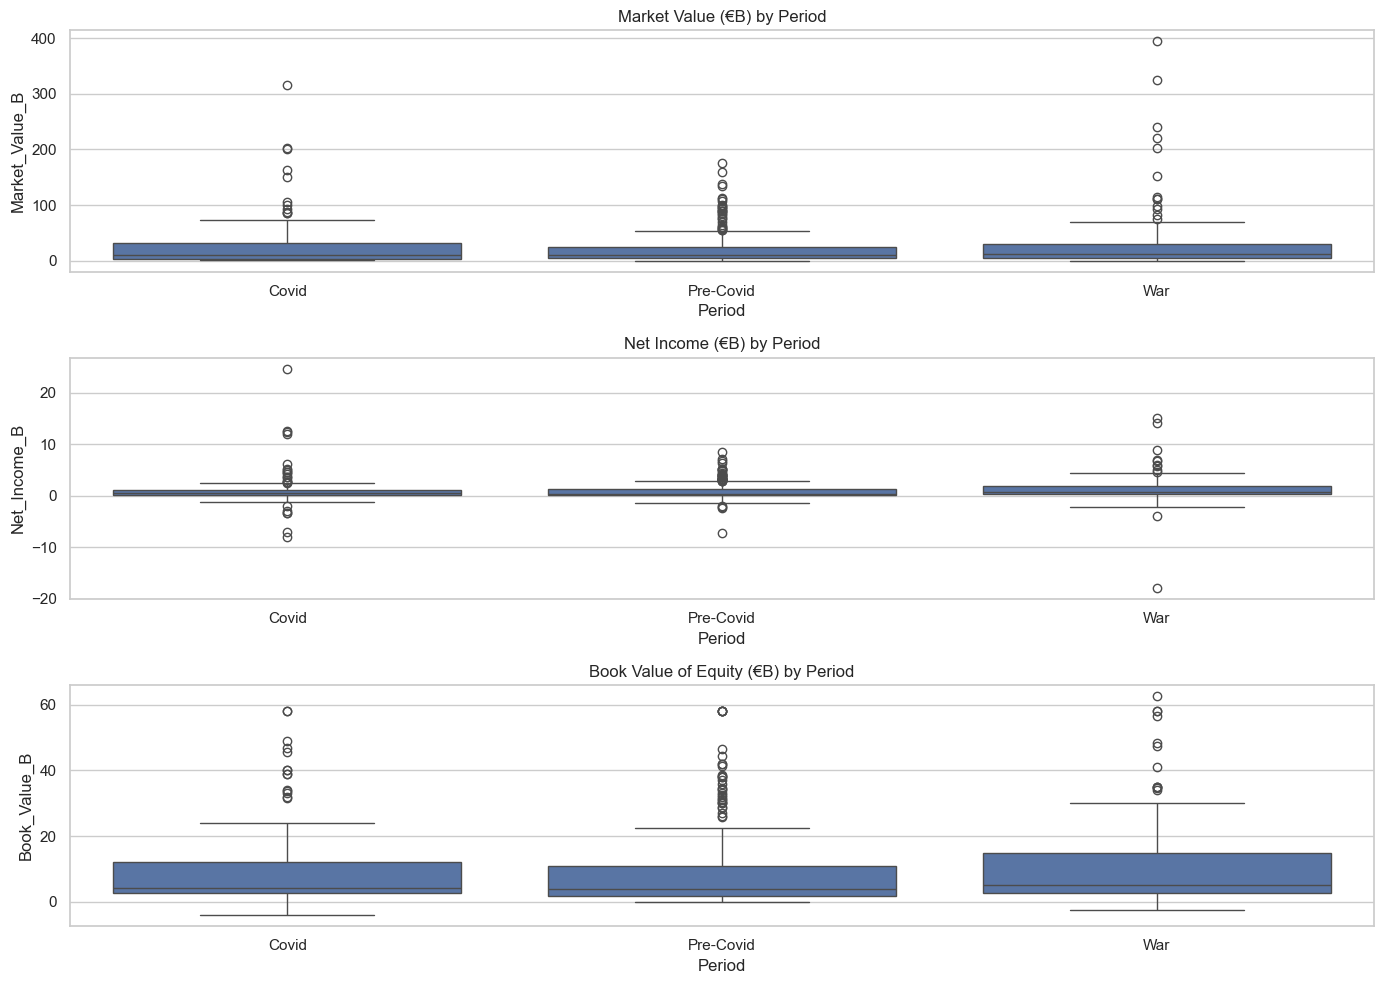

In [37]:
# Boxplots of Market Value, Net Income, and Book Value by Period
plt.figure(figsize=(14, 10))

# 1. Market Value
plt.subplot(3, 1, 1)
sns.boxplot(x='Period', y='Market_Value_B', data=df)
plt.title('Market Value (€B) by Period')

# 2. Net Income
plt.subplot(3, 1, 2)
sns.boxplot(x='Period', y='Net_Income_B', data=df)
plt.title('Net Income (€B) by Period')

# 3. Book Value
plt.subplot(3, 1, 3)
sns.boxplot(x='Period', y='Book_Value_B', data=df)
plt.title('Book Value of Equity (€B) by Period')

plt.tight_layout()
plt.show()


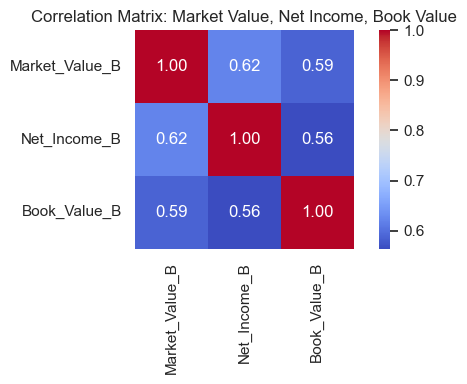

In [39]:
# Create correlation matrix of main financial variables
corr_data = df[['Market_Value_B', 'Net_Income_B', 'Book_Value_B']]
corr_matrix = corr_data.corr()

#  Heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title('Correlation Matrix: Market Value, Net Income, Book Value')
plt.tight_layout()
plt.show()


In [41]:
#  Reset index so Company is available for the regression formula
df_reset = df.reset_index()

#  Fixed Effects regression with Company dummies
model_fe = smf.ols(
    formula='Market_Value_B ~ Net_Income_B + Book_Value_B + C(Company)',
    data=df_reset
).fit(cov_type='HC3')  # HC3 = robust standard errors

print(model_fe.summary())


                            OLS Regression Results                            
Dep. Variable:         Market_Value_B   R-squared:                       0.852
Model:                            OLS   Adj. R-squared:                  0.833
Method:                 Least Squares   F-statistic:                     931.8
Date:                Mon, 10 Nov 2025   Prob (F-statistic):               0.00
Time:                        15:17:29   Log-Likelihood:                -2430.1
No. Observations:                 585   AIC:                             4994.
Df Residuals:                     518   BIC:                             5287.
Df Model:                          66                                         
Covariance Type:                  HC3                                         
                                            coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------

In [43]:
# Create a fresh copy and reset index to access columns
df_periods = df.reset_index()


In [45]:
# Define period masks
pre_covid_mask = df_periods['Year'].between(2015, 2019)
covid_mask     = df_periods['Year'].between(2020, 2021)
war_mask       = df_periods['Year'].between(2022, 2023)


In [47]:
# Fixed Effects Regression for Pre-COVID (2015–2019)
model_pre_covid = smf.ols(
    formula='Market_Value_B ~ Net_Income_B + Book_Value_B + C(Company)',
    data=df_periods[pre_covid_mask]
).fit(cov_type='HC3')

print("Pre-COVID (2015–2019) Regression Results:")
print(model_pre_covid.summary())


Pre-COVID (2015–2019) Regression Results:
                            OLS Regression Results                            
Dep. Variable:         Market_Value_B   R-squared:                       0.844
Model:                            OLS   Adj. R-squared:                  0.804
Method:                 Least Squares   F-statistic:                     361.8
Date:                Mon, 10 Nov 2025   Prob (F-statistic):          2.23e-221
Time:                        15:17:34   Log-Likelihood:                -1226.4
No. Observations:                 325   AIC:                             2587.
Df Residuals:                     258   BIC:                             2840.
Df Model:                          66                                         
Covariance Type:                  HC3                                         
                                            coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------

In [49]:
pre_covid_df = df[df['Period'] == 'Pre-Covid']

In [51]:
pre_covid_df.shape
pre_covid_df[['Book_Value_B', 'Market_Value_B']].describe()


,Book_Value_B,Market_Value_B
count,325.000000,325.000000
mean,8.634532,19.206628
std,11.424013,26.720749
min,0.023000,0.185000
25%,1.800000,4.000000
50%,3.771000,9.330000
75%,11.008000,24.000000
max,58.070000,176.030000


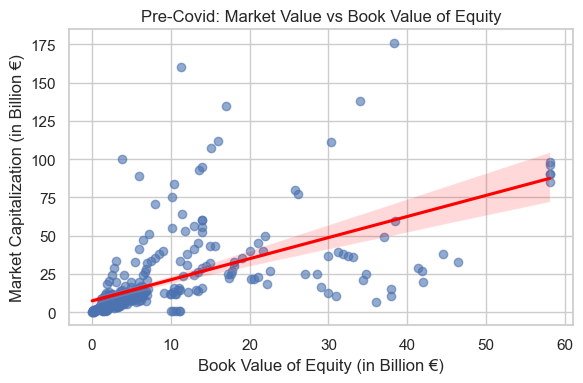

In [57]:
plt.figure(figsize=(6, 4))
sns.regplot(
    data=pre_covid_df,
    x='Book_Value_B',
    y='Market_Value_B',
    scatter_kws={'alpha': 0.6},
    line_kws={"color": "red"}
)
plt.title('Pre-Covid: Market Value vs Book Value of Equity')
plt.xlabel('Book Value of Equity (in Billion €)')
plt.ylabel('Market Capitalization (in Billion €)')
plt.grid(True)
plt.tight_layout()
plt.savefig("precov1.png", dpi=300, bbox_inches='tight')
plt.show()


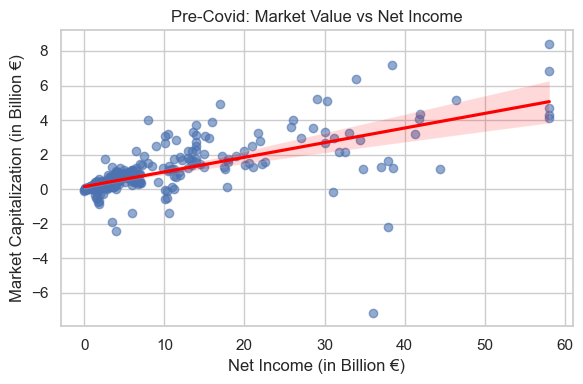

In [59]:
plt.figure(figsize=(6, 4))
sns.regplot(
    data=pre_covid_df,
    x='Book_Value_B',
    y='Net_Income_B',
    scatter_kws={'alpha': 0.6},
    line_kws={"color": "red"}
)
plt.title('Pre-Covid: Market Value vs Net Income')
plt.xlabel('Net Income (in Billion €)')
plt.ylabel('Market Capitalization (in Billion €)')
plt.grid(True)
plt.tight_layout()
plt.savefig("precov2.png", dpi=300, bbox_inches='tight')
plt.show()

In [61]:
# Filter for COVID period (2020–2021)
covid_df = df[df['Period'] == 'Covid']

# Run the Fixed Effects regression for COVID
model_covid = smf.ols(
    formula='Market_Value_B ~ Net_Income_B + Book_Value_B + C(Company)',
    data=covid_df.reset_index()
).fit(cov_type='HC3')  # robust errors

print("COVID (2020–2021) Regression Results:")
print(model_covid.summary())


COVID (2020–2021) Regression Results:
                            OLS Regression Results                            
Dep. Variable:         Market_Value_B   R-squared:                       0.981
Model:                            OLS   Adj. R-squared:                  0.961
Method:                 Least Squares   F-statistic:                     1319.
Date:                Mon, 10 Nov 2025   Prob (F-statistic):           1.49e-81
Time:                        15:29:01   Log-Likelihood:                -420.56
No. Observations:                 130   AIC:                             975.1
Df Residuals:                      63   BIC:                             1167.
Df Model:                          66                                         
Covariance Type:                  HC3                                         
                                            coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------

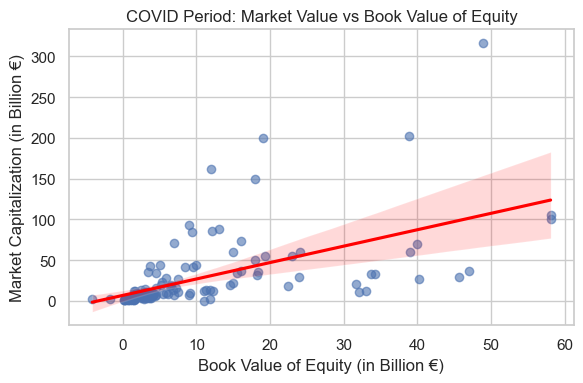

In [65]:
# Filter COVID-period data
covid_df = df[df['Period'] == 'Covid']

# Scatter plot: Market Value vs Book Value during COVID
plt.figure(figsize=(6, 4))
sns.regplot(
    data=covid_df,
    x='Book_Value_B',
    y='Market_Value_B',
    scatter_kws={'alpha': 0.6},
    line_kws={"color": "red"}
)
plt.title('COVID Period: Market Value vs Book Value of Equity')
plt.xlabel('Book Value of Equity (in Billion €)')
plt.ylabel('Market Capitalization (in Billion €)')
plt.grid(True)
plt.tight_layout()
plt.savefig("cov1.png", dpi=300, bbox_inches='tight')
plt.show()


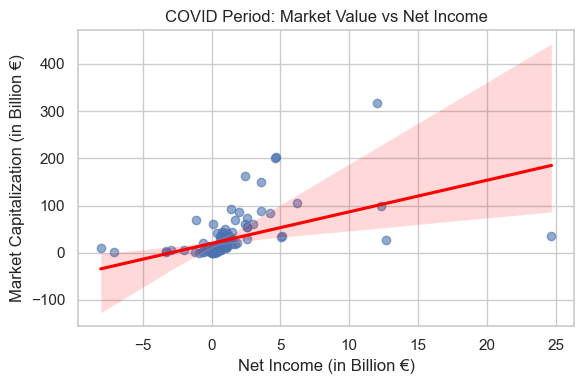

In [67]:
# Scatter plot: Market Value vs Net Income during COVID
plt.figure(figsize=(6, 4))
sns.regplot(
    data=covid_df,
    x='Net_Income_B',
    y='Market_Value_B',
    scatter_kws={'alpha': 0.6},
    line_kws={"color": "red"}
)
plt.title('COVID Period: Market Value vs Net Income')
plt.xlabel('Net Income (in Billion €)')
plt.ylabel('Market Capitalization (in Billion €)')
plt.grid(True)
plt.tight_layout()
plt.savefig("cov2.png", dpi=300, bbox_inches='tight')
plt.show()


In [69]:
# Filter for War period (2022–2023)
war_df = df[df['Period'] == 'War']

# Run the Fixed Effects regression with company dummies
model_war = smf.ols(
    formula='Market_Value_B ~ Net_Income_B + Book_Value_B + C(Company)',
    data=war_df.reset_index()
).fit(cov_type='HC3')  

# Display results
print("War Period (2022–2023) Regression Results:")
print(model_war.summary())


War Period (2022–2023) Regression Results:
                            OLS Regression Results                            
Dep. Variable:         Market_Value_B   R-squared:                       0.990
Model:                            OLS   Adj. R-squared:                  0.981
Method:                 Least Squares   F-statistic:                     7008.
Date:                Mon, 10 Nov 2025   Prob (F-statistic):          2.18e-104
Time:                        15:35:42   Log-Likelihood:                -409.62
No. Observations:                 130   AIC:                             953.2
Df Residuals:                      63   BIC:                             1145.
Df Model:                          66                                         
Covariance Type:                  HC3                                         
                                            coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------

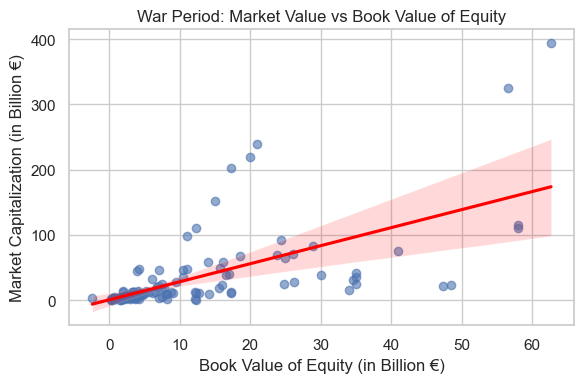

In [71]:
import seaborn as sns
import matplotlib.pyplot as plt

# Scatter + regression line for Book Value
plt.figure(figsize=(6, 4))
sns.regplot(
    data=war_df,
    x='Book_Value_B',
    y='Market_Value_B',
    scatter_kws={'alpha': 0.6},
    line_kws={'color': 'red'}
)
plt.title('War Period: Market Value vs Book Value of Equity')
plt.xlabel('Book Value of Equity (in Billion €)')
plt.ylabel('Market Capitalization (in Billion €)')
plt.tight_layout()
plt.savefig("w1.png", dpi=300, bbox_inches='tight')
plt.show()


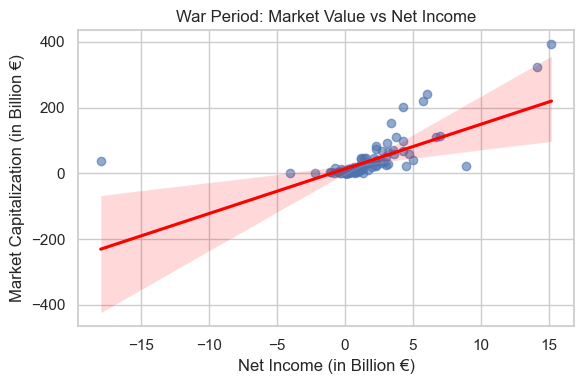

In [73]:
# Scatter + regression line for Net Income
plt.figure(figsize=(6, 4))
sns.regplot(
    data=war_df,
    x='Net_Income_B',
    y='Market_Value_B',
    scatter_kws={'alpha': 0.6},
    line_kws={'color': 'red'}
)
plt.title('War Period: Market Value vs Net Income')
plt.xlabel('Net Income (in Billion €)')
plt.ylabel('Market Capitalization (in Billion €)')
plt.tight_layout()
plt.savefig("w2.png", dpi=300, bbox_inches='tight')
plt.show()


1. Change from 2019 to 2020 (COVID shock)

In [75]:
# Filter data for 2019 and 2020 only
shock_2019_2020 = df_reset[df_reset['Year'].isin([2019, 2020])]

model_2019_2020 = smf.ols(
    formula='Market_Value_B ~ Net_Income_B + Book_Value_B + C(Company)',
    data=shock_2019_2020
).fit(cov_type='HC3')  

print("2019 to 2020 Regression Results:\n")
print(model_2019_2020.summary())


2019 to 2020 Regression Results:

                            OLS Regression Results                            
Dep. Variable:         Market_Value_B   R-squared:                       0.992
Model:                            OLS   Adj. R-squared:                  0.983
Method:                 Least Squares   F-statistic:                     3235.
Date:                Mon, 10 Nov 2025   Prob (F-statistic):           8.10e-94
Time:                        15:45:06   Log-Likelihood:                -330.29
No. Observations:                 130   AIC:                             794.6
Df Residuals:                      63   BIC:                             986.7
Df Model:                          66                                         
Covariance Type:                  HC3                                         
                                            coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------

2. Change from 2021 to 2022 (Pandemic to War transition)

In [78]:
# Filter data for 2021 and 2022 only
shock_2021_2022 = df_reset[df_reset['Year'].isin([2021, 2022])]

model_2021_2022 = smf.ols(
    formula='Market_Value_B ~ Net_Income_B + Book_Value_B + C(Company)',
    data=shock_2021_2022
).fit(cov_type='HC3') 

print("2021 to 2022 Regression Results:\n")
print(model_2021_2022.summary())


2021 to 2022 Regression Results:

                            OLS Regression Results                            
Dep. Variable:         Market_Value_B   R-squared:                       0.996
Model:                            OLS   Adj. R-squared:                  0.993
Method:                 Least Squares   F-statistic:                     333.5
Date:                Mon, 10 Nov 2025   Prob (F-statistic):           8.36e-63
Time:                        15:45:10   Log-Likelihood:                -332.79
No. Observations:                 130   AIC:                             799.6
Df Residuals:                      63   BIC:                             991.7
Df Model:                          66                                         
Covariance Type:                  HC3                                         
                                            coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------

In [37]:
print(shock_2019_2020.shape)
print(shock_2021_2022.shape)


(130, 9)
(130, 9)


## 1 Market Value Change by Company (Bar Plot)

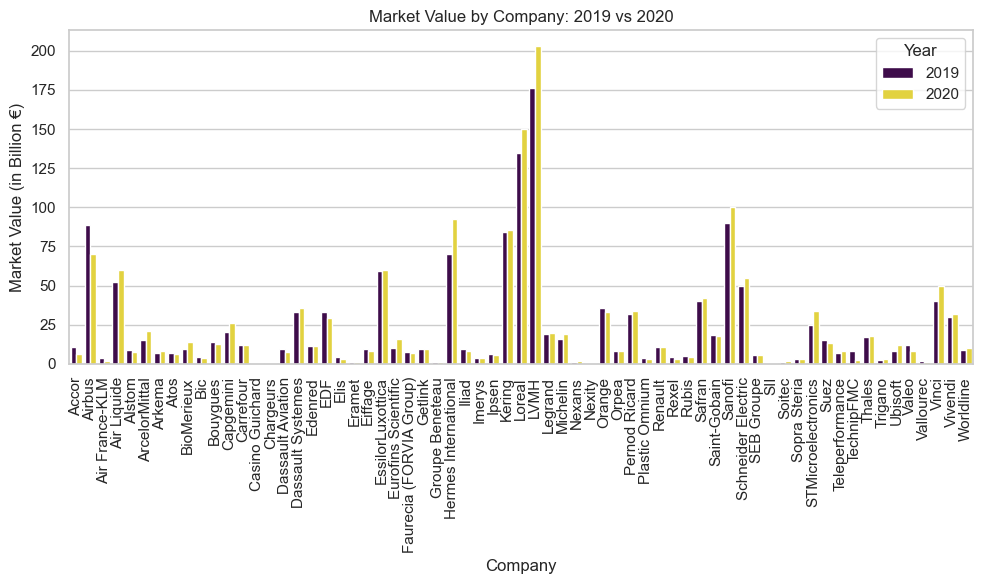

In [90]:
# Grouped bar plot: Market Value by Company for 2019 and 2020
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=shock_2019_2020, x='Company', y='Market_Value_B', hue='Year', palette='viridis')
plt.title('Market Value by Company: 2019 vs 2020')
plt.xticks(rotation=90)
plt.ylabel('Market Value (in Billion €)')
plt.tight_layout()
plt.savefig("pcc1.png", dpi=300, bbox_inches='tight')
plt.show()


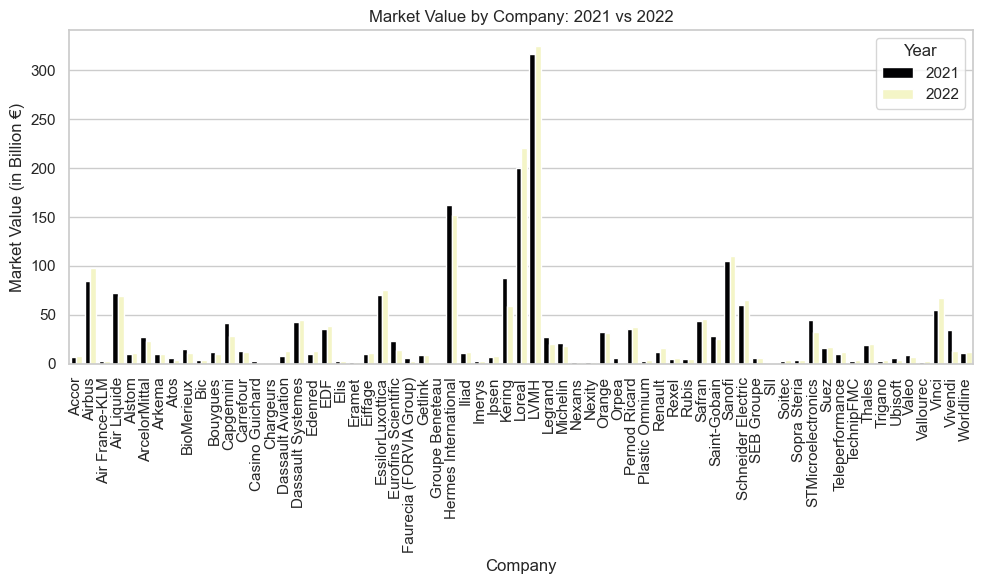

In [94]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=shock_2021_2022, x='Company', y='Market_Value_B', hue='Year', palette='magma')
plt.title('Market Value by Company: 2021 vs 2022')
plt.xticks(rotation=90)
plt.ylabel('Market Value (in Billion €)')
plt.tight_layout()
plt.savefig("pww1.png", dpi=300, bbox_inches='tight')
plt.show()


## 2. Change in Market Value (Delta Plot)

/var/folders/p5/w_ytdxqx5clg6qytykbf05700000gn/T/ipykernel_77277/2694337226.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=delta_mv_19_20.index, y=delta_mv_19_20['Delta'], palette='coolwarm')


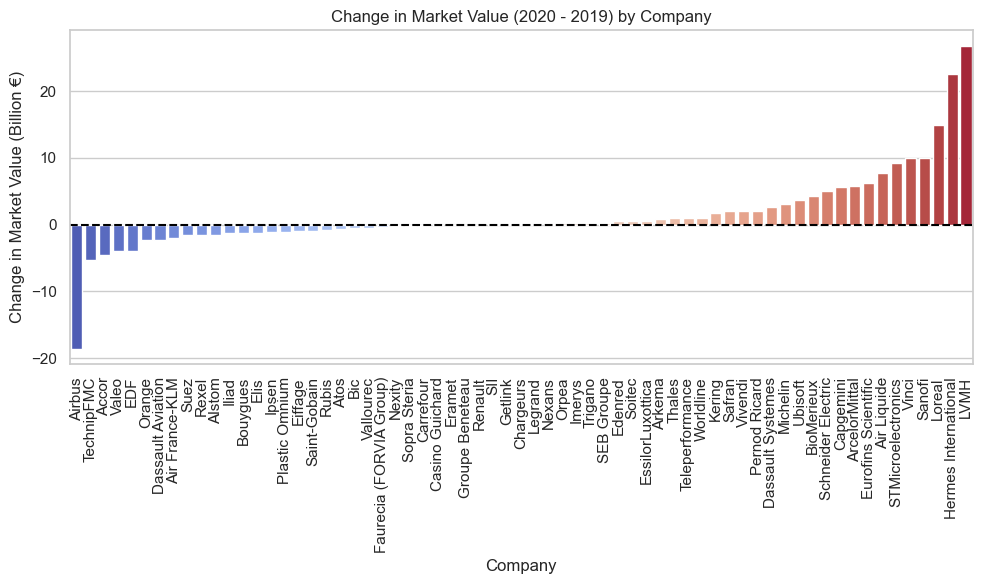

In [92]:
# Calculate market value delta
delta_mv_19_20 = shock_2019_2020.pivot(index='Company', columns='Year', values='Market_Value_B')
delta_mv_19_20['Delta'] = delta_mv_19_20[2020] - delta_mv_19_20[2019]
delta_mv_19_20 = delta_mv_19_20.sort_values(by='Delta')

# Plot the delta
plt.figure(figsize=(10, 6))
sns.barplot(x=delta_mv_19_20.index, y=delta_mv_19_20['Delta'], palette='coolwarm')
plt.title('Change in Market Value (2020 - 2019) by Company')
plt.xticks(rotation=90)
plt.ylabel('Change in Market Value (Billion €)')
plt.axhline(0, color='black', linestyle='--')
plt.tight_layout()
plt.savefig("pcc2.png", dpi=300, bbox_inches='tight')
plt.show()


/var/folders/p5/w_ytdxqx5clg6qytykbf05700000gn/T/ipykernel_77277/3238019480.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=delta_mv_21_22.index, y=delta_mv_21_22['Delta'], palette='Spectral')


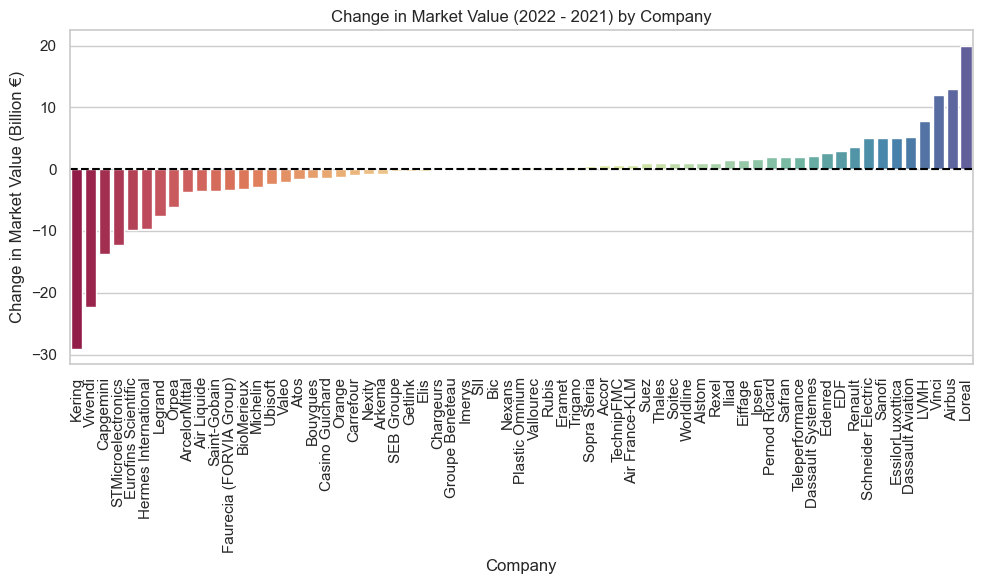

In [96]:
# Calculate market value delta for 2021–2022
delta_mv_21_22 = shock_2021_2022.pivot(index='Company', columns='Year', values='Market_Value_B')
delta_mv_21_22['Delta'] = delta_mv_21_22[2022] - delta_mv_21_22[2021]
delta_mv_21_22 = delta_mv_21_22.sort_values(by='Delta')

# Plot the delta
plt.figure(figsize=(10, 6))
sns.barplot(x=delta_mv_21_22.index, y=delta_mv_21_22['Delta'], palette='Spectral')
plt.title('Change in Market Value (2022 - 2021) by Company')
plt.xticks(rotation=90)
plt.ylabel('Change in Market Value (Billion €)')
plt.axhline(0, color='black', linestyle='--')
plt.tight_layout()
plt.savefig("pww2.png", dpi=300, bbox_inches='tight')
plt.show()
